In [17]:
from Data.fyers_data_final import *
import pandas as pd
import numpy as np
from collections import defaultdict
import math

# Optional HMM
try:
    from hmmlearn.hmm import GaussianHMM
    HMM_AVAILABLE = True
except:
    HMM_AVAILABLE = False


In [128]:
scanner = FyersDataScanner()
scanner.start_date ='2025-11-15 16:15:00'
scanner.end_date = '2025-11-20 16:15:00'
scanner.symbol = 'BSE:SENSEX25N2084600CE'
scanner.resolution = '5S'
            

In [129]:
df = scanner.get_data()

/home/sham/Desktop/TradingAPP/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api-t1.fyers.in'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2025-11-20 02:56:47.018 | ERROR    | Data.DATA_SOURCE:get_data:100 - Error in fetching data: 6 columns passed, passed data had 7 columns


In [130]:
ndf = df [['datetime','Open','Close','High','Low','Vol','TradeVol']].copy()
# timestamp,open,high,low,close,volume
ndf.rename(columns={'Vol':'volume','datetime':'timestamp','Open':'open','Close':'close','High':'high','Low':'low','TradeVol':'trade_volume'},inplace=True)
ndf.to_csv('data.csv',index=False)

In [131]:
def get_state_simple(ret, up=0.001, down=-0.001):
    if np.isnan(ret):
        return None
    if ret > up: return "U"
    if ret < down: return "D"
    return "F"

def add_states(df, up=0.001, down=-0.001):
    df = df.copy()
    df["return"] = df["close"].pct_change()
    df["state"] = df["return"].apply(lambda r: get_state_simple(r, up, down))
    df = df.dropna(subset=["state"]).reset_index(drop=True)
    return df


In [132]:
def build_transition_matrix(states, labels=["U","F","D"]):
    matrix = pd.DataFrame(0, index=labels, columns=labels, dtype=float)
    for i in range(1, len(states)):
        matrix.loc[states[i-1], states[i]] += 1
    matrix = matrix.div(matrix.sum(axis=1).replace(0,1), axis=0)
    return matrix

def predict_next_state_prob(matrix, current_state):
    return matrix.loc[current_state].to_dict()


In [133]:
def build_nstep_transitions(states, N=3):
    trans = {}
    for i in range(N, len(states)):
        prev = "".join(states[i-N:i])
        nxt = states[i]
        if prev not in trans:
            trans[prev] = defaultdict(int)
        trans[prev][nxt] += 1

    # convert counts to probabilities
    for seq in trans:
        total = sum(trans[seq].values())
        for k in trans[seq]:
            trans[seq][k] /= total
    return trans


In [134]:
def train_hmm(df, n_states=3):
    if not HMM_AVAILABLE:
        raise ValueError("Install hmmlearn to use HMM")

    df2 = df.copy()
    df2["return"] = df2["close"].pct_change()
    df2["vol"] = df2["return"].rolling(10).std().fillna(0)
    df2 = df2.dropna()

    X = df2[["return","vol"]].values

    model = GaussianHMM(n_components=n_states, covariance_type="full", n_iter=200)
    model.fit(X)
    df2["hmm_state"] = model.predict(X)

    return model, df2


In [135]:
def compute_metrics(equity):
    ret = equity.pct_change().fillna(0)
    total_return = equity.iloc[-1]/equity.iloc[0] - 1

    annual_factor = 252 * 4680 # 252 trading days, 4680 minutes in a day
    if ret.std() == 0:
        sharpe = np.nan
    else:
        sharpe = (ret.mean()*annual_factor) / (ret.std()*np.sqrt(annual_factor))

    high = equity.cummax()
    dd = (equity - high) / high
    max_dd = dd.min()

    return dict(total_return=total_return, sharpe=sharpe, max_drawdown=max_dd)

def backtest(df, signals, capital=100000):
    df = df.reset_index(drop=True)
    cash = capital
    pos = 0
    equity = []

    for i in range(len(df)):
        price = df.loc[i,"close"]
        sig = signals[i]

        # close old position if reversing
        if pos != 0 and np.sign(pos) != sig:
            cash += pos * price
            pos = 0

        # open
        if sig != 0 and pos == 0:
            pos = (cash * 0.1) / price * sig
            cash -= pos * price

        # equity update
        total_equity = cash + pos*price
        equity.append(total_equity)

    equity = pd.Series(equity)
    return equity, compute_metrics(equity)


In [136]:
def generate_ma(df, short=5, long=20):
    df = df.copy()
    df["ma_s"] = df["close"].rolling(short).mean()
    df["ma_l"] = df["close"].rolling(long).mean()
    sig = (df["ma_s"] > df["ma_l"]).astype(int)
    sig[df["ma_s"] < df["ma_l"]] = -1
    return sig.fillna(0)

def full_markov_bot(df, p_thresh=0.4, short=5, long=20):
    df2 = add_states(df)
    states = df2["state"].values
    matrix = build_transition_matrix(states)

    ma_sig = generate_ma(df2, short, long)

    signals = []
    for i in range(len(df2)):
        if i == 0:
            signals.append(0)
            continue

        probs = predict_next_state_prob(matrix, states[i-1])
        if probs["U"] > p_thresh and ma_sig.iloc[i] == 1:
            signals.append(1)
        elif probs["D"] > p_thresh and ma_sig.iloc[i] == -1:
            signals.append(-1)
        else:
            signals.append(0)

    signals = pd.Series(signals)
    return backtest(df2, signals)


In [137]:
def backtest_with_trades(df, signals, capital=100000, fee=0.0, slippage=0.0):
    """
    df: dataframe with at least 'close'
    signals: Series of -1, 0, 1 (short, flat, long)
    """
    df = df.reset_index(drop=True)

    cash = capital
    position = 0.0
    entry_price = None
    entry_index = None
    trades = []

    equity_list = []

    for i in range(len(df)):
        price = df.loc[i, "close"]
        sig = signals.iloc[i]

        # =======================
        # CLOSE POSITION
        # =======================
        if position != 0 and np.sign(position) != sig:
            exit_price = price
            pl = position * (exit_price - entry_price)

            pl -= abs(position) * fee
            pl -= abs(position) * slippage

            cash += position * exit_price
            trades.append({
                "entry_index": entry_index,
                "exit_index": i,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "position": position,
                "pnl": pl,
                "duration_bars": i - entry_index
            })
            position = 0.0
            entry_price = None
            entry_index = None

        # =======================
        # OPEN NEW POSITION
        # =======================
        if sig != 0 and position == 0:
            position = (cash * 0.1) / price * sig
            entry_price = price
            entry_index = i
            cash -= position * price

        # =======================
        # EQUITY UPDATE
        # =======================
        equity_list.append(cash + position * price)

    equity = pd.Series(equity_list)
    trades_df = pd.DataFrame(trades)

    return equity, trades_df


In [138]:
# Load your intraday DataFrame however you want
df = ndf   # ← replace with your df (no CSV needed)

df_states = add_states(df)
states = df_states["state"].values

# 1-step Markov
mat = build_transition_matrix(states)
mat


,U,F,D
U,0.383560,0.166285,0.450155
F,0.380890,0.202552,0.416558
D,0.455187,0.159941,0.384871


In [139]:
current = states[-1]
predict_next_state_prob(mat, current)


{'U': 0.45518710880277, 'F': 0.1599414036489546, 'D': 0.3848714875482754}

In [140]:
ntrans = build_nstep_transitions(states, N=3)
list(ntrans.items())[:5]


[('DDU',
  defaultdict(int,
              {'U': 0.413768115942029,
               'D': 0.41884057971014493,
               'F': 0.1673913043478261})),
 ('DUU',
  defaultdict(int,
              {'U': 0.3983618763961281,
               'D': 0.4527177959791511,
               'F': 0.14892032762472077})),
 ('UUU',
  defaultdict(int,
              {'D': 0.49193548387096775,
               'U': 0.39157706093189965,
               'F': 0.11648745519713262})),
 ('UUD',
  defaultdict(int,
              {'D': 0.4068810770381451,
               'U': 0.4293193717277487,
               'F': 0.1637995512341062})),
 ('UDD',
  defaultdict(int,
              {'D': 0.36289726533628974,
               'U': 0.47671840354767187,
               'F': 0.16038433111603842}))]

{'total_return': np.float64(0.03428865627253774),
 'sharpe': np.float64(4.089455086327283),
 'max_drawdown': np.float64(-0.07040616452502005)}

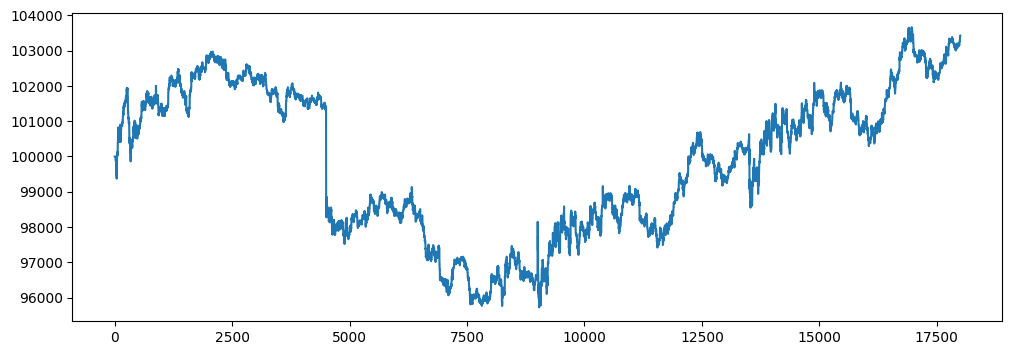

In [141]:
equity, metrics = full_markov_bot(df, p_thresh=0.4)
equity.plot(figsize=(12,4))
metrics


OPTION 1 — Simple 1-step Markov Signals (Recommended for Testing)

In [142]:
df2 = add_states(ndf)
states = df2["state"].values

mat = build_transition_matrix(states)

signals = []
p_thresh = 0.4   # adjust as needed

for i in range(len(states)):
    if i == 0:
        signals.append(0)
        continue
    
    probs = predict_next_state_prob(mat, states[i-1])

    if probs["U"] > p_thresh:
        signals.append(1)
    elif probs["D"] > p_thresh:
        signals.append(-1)
    else:
        signals.append(0)

signals = pd.Series(signals)


In [143]:
equity, trades = backtest_with_trades(df2, signals)


In [144]:
trades

,entry_index,exit_index,entry_price,exit_price,position,pnl,duration_bars
0,1,3,521.00,534.95,19.193858,267.754319,2
1,3,6,534.95,553.05,-18.743388,-339.255324,3
2,6,11,553.05,503.30,18.068619,-898.913810,5
3,11,12,503.30,489.35,-19.676055,274.480968,1
4,12,18,489.35,477.00,20.293055,-250.619233,6
...,...,...,...,...,...,...,...
9232,17983,17985,588.00,592.85,21.304910,103.328812,2
9233,17985,17991,592.85,593.45,-21.148047,-12.688828,6
9234,17991,17992,593.45,596.60,21.124528,66.542262,1
9235,17992,17994,596.60,592.00,-21.024145,96.711068,2


<Axes: >

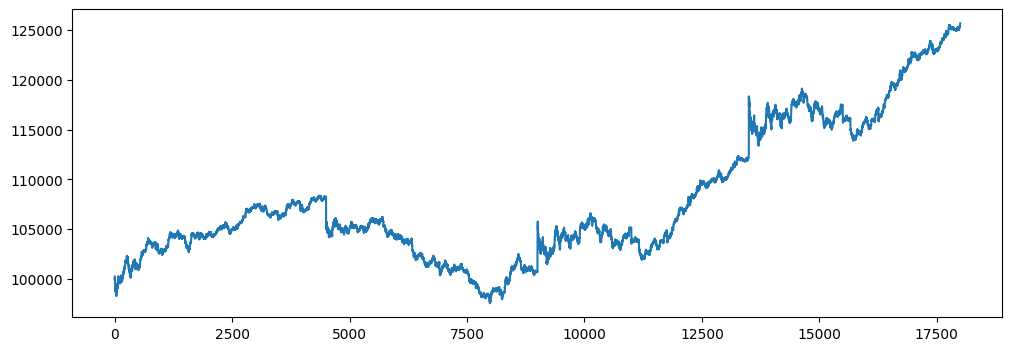

In [145]:
equity.plot(figsize=(12,4))

OPTION 2 — N-step Markov Signals

In [160]:
df2 = add_states(ndf)
states = df2["state"].values

N = 3
p_thresh = 0.4

ntrans = build_nstep_transitions(states, N)

signals = []

for i in range(len(states)):
    if i < N:
        signals.append(0)
        continue
    
    seq = "".join(states[i-N:i])
    probs = ntrans.get(seq, None)

    if not probs:
        signals.append(0)
        continue

    if probs.get("U", 0) > p_thresh:
        signals.append(1)
    elif probs.get("D", 0) > p_thresh:
        signals.append(-1)
    else:
        signals.append(0)

signals = pd.Series(signals)


In [161]:
equity, trades = backtest_with_trades(df2, signals)


<Axes: >

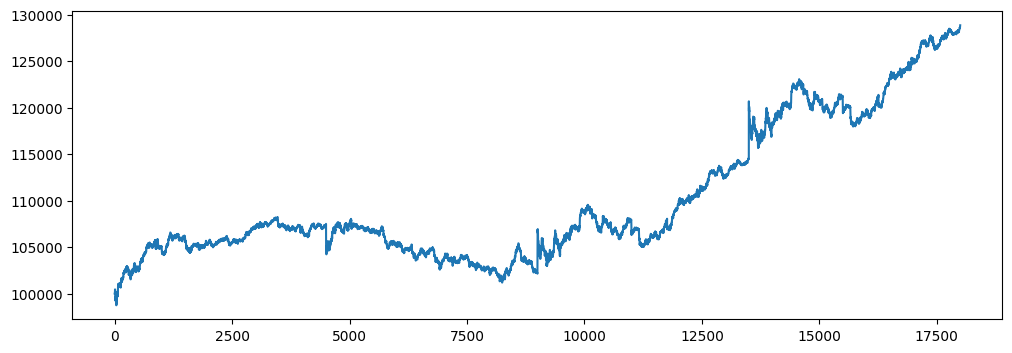

In [162]:
equity.plot(figsize=(12,4))

In [159]:
trades

,entry_index,exit_index,entry_price,exit_price,position,pnl,duration_bars
0,3,4,534.95,556.55,18.693336,403.776054,1
1,4,6,556.55,553.05,-18.040387,63.141356,2
2,6,11,553.05,503.30,18.165974,-903.757190,5
3,11,12,503.30,489.35,-19.782070,275.959882,1
4,12,19,489.35,472.75,20.402395,-338.679758,7
...,...,...,...,...,...,...,...
7934,17988,17989,594.00,594.90,21.643919,19.479527,1
7935,17989,17991,594.90,593.45,-21.614449,31.340952,2
7936,17991,17993,593.45,594.15,21.672542,15.170779,2
7937,17993,17994,594.15,592.00,-21.649562,46.546558,1


OPTION 3 — Markov + Moving Average Filter (Most Reliable)

In [149]:
df2 = add_states(ndf)
states = df2["state"].values

mat = build_transition_matrix(states)
ma_sig = generate_ma(df2, short=10, long=40)

p_thresh = 0.4
signals = []

for i in range(len(states)):
    if i == 0:
        signals.append(0)
        continue
    
    probs = predict_next_state_prob(mat, states[i-1])

    if probs["U"] > p_thresh and ma_sig.iloc[i] == 1:
        signals.append(1)
    elif probs["D"] > p_thresh and ma_sig.iloc[i] == -1:
        signals.append(-1)
    else:
        signals.append(0)

signals = pd.Series(signals)


In [150]:
equity, trades = backtest_with_trades(df2, signals)


In [151]:
trades

,entry_index,exit_index,entry_price,exit_price,position,pnl,duration_bars
0,41,43,484.05,502.35,20.659023,378.060118,2
1,46,48,489.55,496.85,20.504149,149.680286,2
2,49,50,500.10,506.95,20.101528,137.695465,1
3,54,55,529.90,535.10,18.997063,98.784727,1
4,58,59,536.15,532.35,18.794035,-71.417334,1
...,...,...,...,...,...,...,...
4762,17975,17977,589.95,590.90,19.076873,18.123029,2
4763,17980,17981,590.50,591.95,19.062173,27.640151,1
4764,17983,17985,588.00,592.85,19.147921,92.867415,2
4765,17991,17992,593.45,596.60,18.987723,59.811327,1


<Axes: >

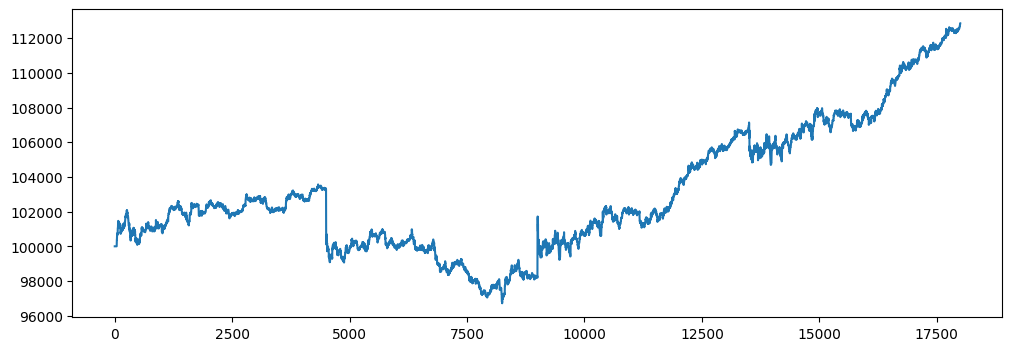

In [152]:
equity.plot(figsize=(12,4))